Example: Customer Segmentation for a Retail Company 🛍️

 Business Context

A retail chain wants to understand its customers better. Instead of treating everyone the same,they want to group customers into segments (like “budget shoppers,” “loyal premium buyers,” etc.)so they can:
- Personalize marketing campaigns
- Recommend products more effectively
- Improve customer retention

Dataset (simplified)
Imagine we have customer data with features like:
- Annual Income (numeric)
- Spending Score (numeric, based on purchase behavior)
- Age (numeric)

   CustomerID  Age  AnnualIncome  SpendingScore  Cluster
0           1   25         25000             30        2
1           2   45         60000             70        1
2           3   35         40000             50        0
3           4   23         20000             20        2
4           5   52         80000             90        1
5           6   40         50000             60        0


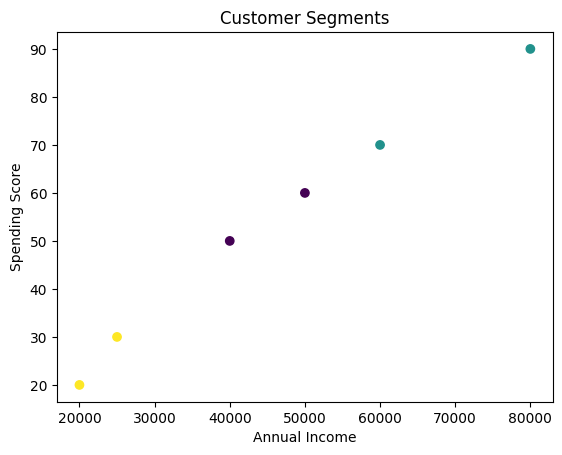

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
data = {
    'CustomerID': [1,2,3,4,5,6],
    'Age': [25,45,35,23,52,40],
    'AnnualIncome': [25000,60000,40000,20000,80000,50000],
    'SpendingScore': [30,70,50,20,90,60]
}

df=pd.DataFrame(data)

X=df[['Age','AnnualIncome','SpendingScore']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

kmeans=KMeans(n_clusters=3,random_state=42)
df['Cluster']=kmeans.fit_predict(X_scaled)

print(df)

plt.scatter(df['AnnualIncome'],df['SpendingScore'],c=df['Cluster'],cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

Example: Hospital Patient Segmentation 🏥

Business Context

 A hospital wants to improve patient care and resource allocation. Instead of treating all
patients the same, they want to group them into segments based on health and lifestyle data.

This helps with:
- Designing personalized treatment plans
- Predicting high‑risk patients
- Managing hospital resources more efficiently

Dataset (simplified)

Features we might use:
- Age
- BMI (Body Mass Index)
- Number of yearly hospital visits
- Chronic conditions count

   PatientID  Age  BMI  HospitalVisits  ChronicConditions  Cluster
0        101   25   22               1                  0        2
1        102   60   30               5                  2        0
2        103   45   28               3                  1        0
3        104   30   24               2                  0        2
4        105   70   35               7                  3        1
5        106   50   27               4                  1        0


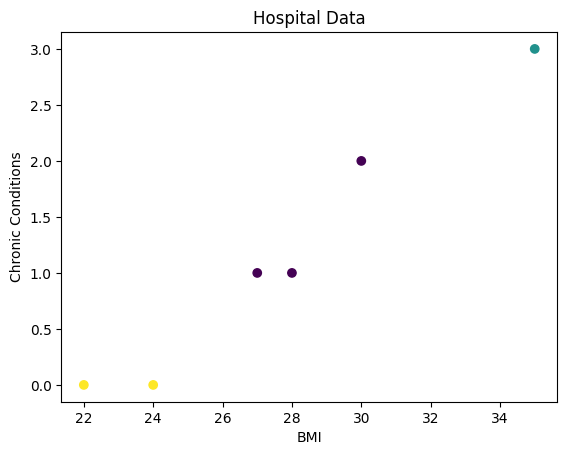

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
data = {
    'PatientID': [101,102,103,104,105,106],
    'Age': [25,60,45,30,70,50],
    'BMI': [22,30,28,24,35,27],
    'HospitalVisits': [1,5,3,2,7,4],
    'ChronicConditions': [0,2,1,0,3,1]
}
df=pd.DataFrame(data)

X=df[['Age','BMI','HospitalVisits','ChronicConditions']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

kmeans=KMeans(n_clusters=3,random_state=42)
df['Cluster']=kmeans.fit_predict(X_scaled)
print(df)


plt.scatter(df['BMI'],df['ChronicConditions'],c=df['Cluster'],cmap='viridis')
plt.xlabel('BMI')
plt.ylabel('Chronic Conditions')
plt.title('Hospital Data')
plt.show()

 Scenario Question 💼

 A telecommunications company has collected data on 500 customers, including their monthly bill
amount, average call duration, internet usage, and number of support calls. The company wants
to group customers into meaningful segments to design targeted marketing campaigns and improve customer
 service.

You are tasked with:
 - Using K‑Means clustering to explore possible customer segments.
 - Applying the Elbow Method to determine where adding more clusters stops giving significant improvement.
 - Using the Silhouette Score to validate which number of clusters produces the most well‑separated and meaningful groups.


Scenario Question 💼

A telecommunications company has collected data on 500 customers, including their monthly bill amount, average call duration, internet usage, and number of support calls. The company wants to group customers into meaningful segments to design targeted marketing campaigns and improve customer service.

You are tasked with:
- Using K‑Means clustering to explore possible customer segments.
- Applying the Elbow Method to determine where adding more clusters stops giving significant improvement.
- Using the Silhouette Score to validate which number of clusters produces the most well‑separated and meaningful groups

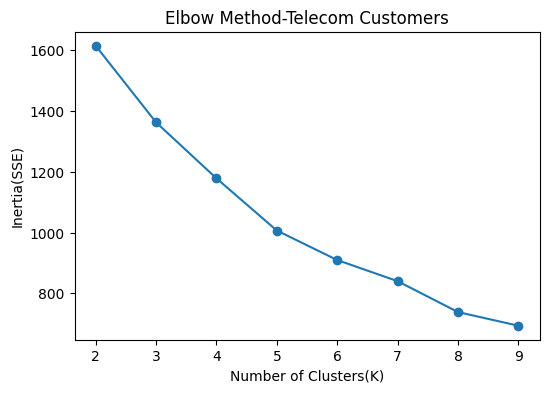

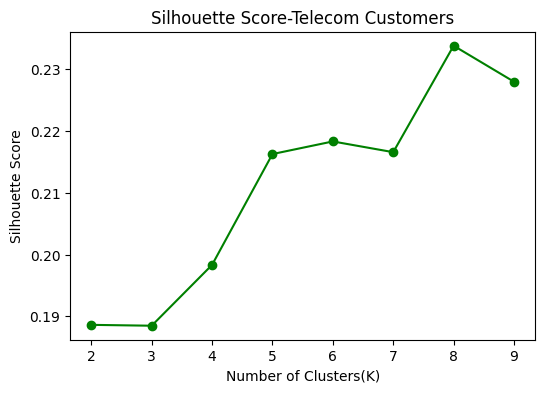

Ideal Number of Clusters: 8


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

data = {
    'CustomerID': range(1, 501),
    'MonthlyBill': np.random.randint(20, 200, 500),       # monthly bill in $
    'CallDuration': np.random.randint(50, 500, 500),      # avg monthly call minutes
    'InternetUsage': np.random.randint(10, 300, 500),     # GB per month
    'SupportCalls': np.random.randint(0, 10, 500)         # number of support calls
}
df = pd.DataFrame(data)

X = df[['MonthlyBill', 'CallDuration', 'InternetUsage', 'SupportCalls']]

scalerq = StandardScaler()
X_scaled = scalerq.fit_transform(X)

inertia=[]
K_range=range(2,10)
for k in K_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range,inertia,marker='o')
plt.title('Elbow Method-Telecom Customers')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('Inertia(SSE)')
plt.show()

silhouette_scores=[]
for k in K_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_scaled)
    score=silhouette_score(X_scaled,labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_range,silhouette_scores,marker='o',color='green')
plt.title('Silhouette Score-Telecom Customers')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('Silhouette Score')
plt.show()
print("Ideal Number of Clusters:",np.argmax(silhouette_scores)+2)

🎬 Scenario: Movie Streaming Platform

A movie streaming company has collected data on 1,000 users, including:
- Average watch time per week
- Preferred genres (action, comedy, drama, etc.)
- Number of devices used (TV, phone, tablet)
 - Frequency of subscription pauses or cancellations
The company wants to group users into meaningful segments to:
- Recommend personalized movie lists
- Design loyalty rewards for binge‑watchers
- Identify users at risk of canceling subscriptions
Your Tasks
- Apply K‑Means clustering to explore possible user segments.
- Example clusters: “Weekend binge‑watchers,” “Casual family viewers,” “Genre loyalists.”
- Use the Elbow Method to find the point where adding more clusters doesn’t improve grouping much.
- This helps decide whether 3, 4, or 5 clusters make sense.
- Validate with Silhouette Score to check if the chosen clusters are well‑separated and meaningful.
- Ensures that “binge‑watchers” aren’t mixed up with “casual viewers.”

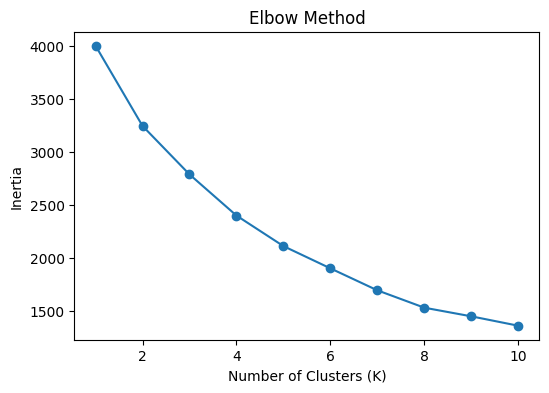

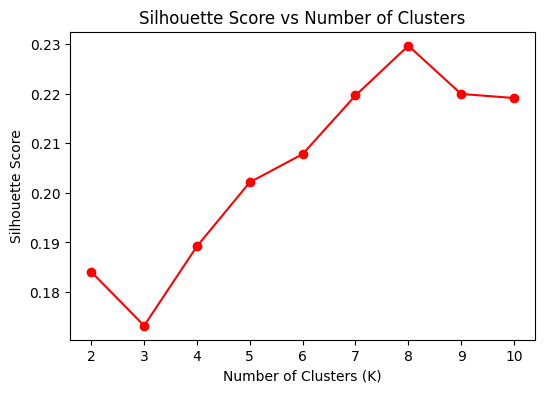

Ideal Number of Clusters (based on Silhouette Score): 8


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np

n=1000
data = pd.DataFrame({
    "Watch_Time":np.random.randint(1,40,n),        # hours per week
    "Preferred_Genre":np.random.randint(1,6,n),    # 1–5 genres
    "Devices_Used":np.random.randint(1,4,n),       # 1–3 devices
    "Subscription_Pauses":np.random.randint(0,6,n) # 0–5 pauses
})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
print()
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o',color='red')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()
ideal_k = K_range[silhouette_scores.index(max(silhouette_scores))]

print("Ideal Number of Clusters (based on Silhouette Score):", ideal_k)

# Hierarchircal Clustering

Scenario Question 💼

A retail bank wants to understand its customers better. They have
collected data on Age and Annual Income for a sample of customers.
 The goal is to group customers into meaningful segments so the bank can
 design targeted loan offers, personalized investment plans, and marketing campaigns.

Cluster Labels: [2 2 2 1 1 0 0 0]


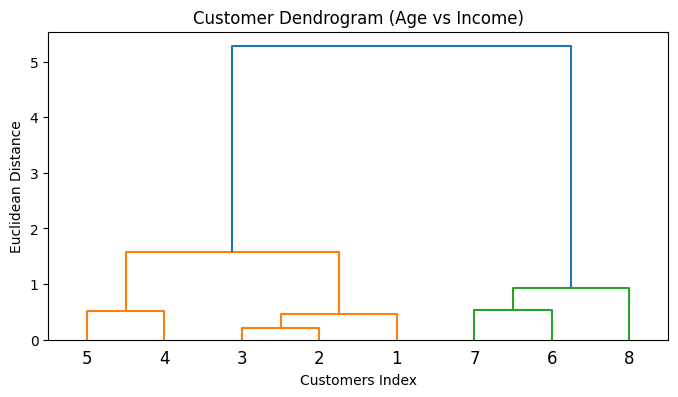

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

data = np.array([
    [25, 15000],
    [28, 16000],
    [30, 18000],
    [35, 22000],
    [40, 25000],
    [45, 60000],
    [50, 65000],
    [55, 70000]
])

scaler=StandardScaler()
data_scaled=scaler.fit_transform(data)

hieraechical_cluster=AgglomerativeClustering(n_clusters=3,linkage='ward')
cluster_labels=hieraechical_cluster.fit_predict(data_scaled)

print("Cluster Labels:",cluster_labels)

linked=linkage(data_scaled,method='ward')

plt.figure(figsize=(8,4))
dendrogram(linked,orientation='top',labels=range(1,len(data_scaled)+1),distance_sort='descending',show_leaf_counts=True)\

plt.title('Customer Dendrogram (Age vs Income)')
plt.xlabel('Customers Index')
plt.ylabel('Euclidean Distance')
plt.show()

 Scenario:

 Employee Segmentation in a Tech Company 💻

 Business Problem
 A tech company wants to understand its employees better to design training programs
 and salary structures. They collected data on each employee’s Age and Annual
 Salary.

 Management believes employees can be grouped into clusters such as:
 - Young, entry‑level employees
 - Mid‑career professionals
 - Senior, high‑earning employees

 They decide to use hierarchical clustering to explore these segments.


 data = np.array([
     [25, 15000],
     [28, 16000],
     [30, 18000],
     [35, 22000],
     [40, 25000],
     [45, 60000],
     [50, 65000],
     [55, 70000]
])

Cluster Labels: [2 2 2 1 1 0 0 0]


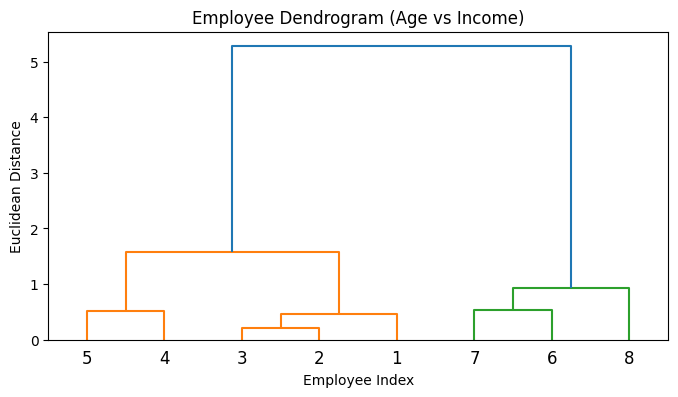

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

data = np.array([ [25, 15000], [28, 16000], [30, 18000], [35, 22000], [40, 25000], [45, 60000], [50, 65000], [55, 70000] ])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

hieraechical_cluster=AgglomerativeClustering(n_clusters=3,linkage='ward')
cluster_labels=hieraechical_cluster.fit_predict(data_scaled)

print("Cluster Labels:",cluster_labels)

linkage=linkage(data_scaled,method='ward')
plt.figure(figsize=(8,4))
dendrogram(linked,orientation='top',labels=range(1,len(data_scaled)+1),distance_sort='descending',show_leaf_counts=True)\

plt.title('Employee Dendrogram (Age vs Income)')
plt.xlabel('Employee Index')
plt.ylabel('Euclidean Distance')
plt.show()